## 문제 1. Projection Matrix 해석
이 행렬이 어떤 의미를 가지는지 설명하고, 다음을 포함하여 해석하시오.
intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미
extrinsic 파라미터 (R, t)의 역할
이 행렬이 3D 점을 이미지 좌표로 어떻게 변환하는지 수식으로 설명


1.개요 및 Projection Matrix 구성
KITTI 데이터셋 Sequence 09의 calib.txt 파일을 파싱하여 좌측 컬러 카메라의 Projection Matrix (P2)를 추출하였습니다. 추출된 3×4 행렬은 다음과 같습니다.

P0=[707.0912    0.0         601.8873    0.0
    0.0         707.0912    183.1104    0.0
    0.0         0.0         1.0         0.0]
​	
2.Intrinsic 파라미터 의미
내부 파라미터(Intrinsic Parameters)는 카메라 렌즈와 센서의 물리적 특성을 나타내며, 3D 공간의 점이 이미지 평면에 어떻게 투영될지 결정합니다.

초점 거리 (f_x, f_y):렌즈의 중심에서 이미지 센서까지의 거리를 픽셀 단위로 환산한 값입니다. 이 수치는 이미지의 수평(f_x),수직 방향(f_y)의 확대 및 축소 비율을 결정하며, 값이 클수록 화각이 좁아지는 망원 특성을, 작을수록 넓은 영역을 담는 광각 특성을 보입니다. sequences 09 데이터에서는 두 값이 동일하게 707.0912 px로 나타나 픽셀의 가로세로 비가 1:1인 정사각형 형태임을 알 수 있습니다.

주점 (c_x, c_y): 카메라 렌즈의 광학적 중심이 이미지 센서와 가로/세로 방향으로 몇 번째 픽셀에 위치하는지를 나타냅니다. 렌즈를 통해 들어온 빛이 맺히는 수학적 중심점을 의미하며, 일반적으로 이미지 해상도의 중앙 근처에 위치합니다. 렌즈의 중심인 주점은 (601.8873, 183.1104) px로 확인되었습니다. 이미지의 기하학적 중심인 (621.0, 187.5)와 비교했을 때, 각각 Δcx=−19.11 px, Δcy=−4.39 px의 미세한 편차가 존재함을 알 수 있습니다.
  
3.Extrinsic 파라미터 해석
회전행렬 (R): 3×4 크기의 Projection Matrix에서 왼쪽 3×3 영역은 내부 행렬(K)과 회전 행렬(R)이 결합된 형태를 가집니다. R은 카메라가 바라보는 방향(Orientation)을 결정하며, 차량의 진행 방향을 기준으로 카메라의 기울어짐(Pitch, Yaw, Roll) 정도를 나타냅니다. 정교하게 정렬된 KITTI 데이터셋에서는 대개 단위 행렬에 가까워 카메라가 정면을 똑바로 응시하고 있음을 의미합니다.

변위 (t): 카메라의 물리적 위치를 정의하며, 기준이 되는 0번 카메라 좌표계로부터의 이동 거리를 나타냅니다. P 행렬의 4번째 열(인덱스 3, 7, 11)이 이 위치 정보에 해당합니다. 이번 결과에서 P2의 t_x 값은 기준점으로부터 약 6.63cm 우측에 위치함을 보여줍니다.

4.3D → 2D 투영 수식

3차원 공간의 점 X=[X,Y,Z,1]^T을 2차원 이미지 좌표 (u, v)로 변환하는 과정은 다음과 같습니다.

[1단계] 행렬 곱을 통한 동차 좌표 산출
[ w⋅u, w⋅v, w]^T = P_2 ⋅ [X,Y,X,1]^T

이를 전개하면 다음과 같은 선형 결합 식이 도출됩니다:

w⋅u=(f_x⋅X)+(c_x⋅Z)+t_x_px
​w⋅v=(f_y⋅Y)+(c_y⋅Z)+t_y_px
​w=Z+t_z_px (여기서 w는 투영 시의 깊이 계수입니다.)

[2단계] 비균질 좌표 변환 (정규화)
이미지 평면의 2차원 픽셀 좌표를 얻기 위해 w 성분으로 각 항을 나눕니다.
u = {(f_x⋅X)+(c_x⋅Z)+t_x_px} / Z+t_z_px 
v = {(f_y⋅Y)+(c_y⋅Z)+t_y_px} / Z+t_z_px

In [40]:
import numpy as np
# ── 문제 1: Projection Matrix 해석 ─────────────────────────────────────────
def parse_kitti_calib(file_path: str) -> dict:

    calib = {}
    with open(file_path, 'r') as f:
        for line in f:
            if not line.strip():
                continue
            key, value = line.split(':', 1)
            calib[key.strip()] = np.array([float(x) for x in value.split()])
    return calib

# ── 실제 데이터 경로 설정  ────────────────────────────────
CALIB_PATH = '/Users/hyunjung/Downloads/dataset/sequences/09/calib.txt'

calib_data = parse_kitti_calib(CALIB_PATH)

P0 = calib_data['P0'].reshape(3, 4)

# ── 파라미터 추출 ────────────────────────────────────────────────────────────
fx = P0[0, 0]
fy = P0[1, 1]
cx = P0[0, 2]
cy = P0[1, 2]
tx = P0[0, 3] / fx   # 기준 카메라 대비 x축 이동 거리 (m)
ty = P0[1, 3] / fy
tz = P0[2, 3]

# ── 결과 출력 ────────────────────────────────────────────────────────────────
print("\n=== Projection Matrix P0 ===")
print(P0)
print("\n=== Intrinsic 파라미터 ===")
print(f"  fx (가로 초점 거리): {fx:.4f} px")
print(f"  fy (세로 초점 거리): {fy:.4f} px")
print(f"  cx (주점 가로 좌표): {cx:.4f} px")
print(f"  cy (주점 세로 좌표): {cy:.4f} px")
print("\n=== Extrinsic 파라미터 (기준 카메라 P0 대비) ===")
print(f"  tx (x축 이동): {tx:.4f} m  (≈ {tx*100:.2f} cm)")
print(f"  ty (y축 이동): {ty:.6f} m")
print(f"  tz (z축 이동): {tz:.6f} m")


=== Projection Matrix P0 ===
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]

=== Intrinsic 파라미터 ===
  fx (가로 초점 거리): 707.0912 px
  fy (세로 초점 거리): 707.0912 px
  cx (주점 가로 좌표): 601.8873 px
  cy (주점 세로 좌표): 183.1104 px

=== Extrinsic 파라미터 (기준 카메라 P0 대비) ===
  tx (x축 이동): 0.0000 m  (≈ 0.00 cm)
  ty (y축 이동): 0.000000 m
  tz (z축 이동): 0.000000 m


## 문제 2. Projection Matrix를 이용한 3D → 2D 투영
임의의 3차원 점들을 생성하고, projection matrix를 이용하여 이미지 좌표로 투영하시오.
투영된 점들을 이미지 위에 시각화하고, 결과가 카메라 투영의 특성과 어떻게 일치하는지 설명하시오.

1.원근 투영의 거리 반비례 특성 (1/Z Scaling)
• 카메라 투영의 가장 대표적인 특성은 물체가 카메라로부터 멀어질수록 이미지 상에서의 크기가 작아지거나 간격이 좁아지는 원근적 수축(Perspective Foreshortening)입니다.
• 수식인 $u = \frac{f_x X + t_{px}}{Z}$와 $v = \frac{f_y Y + t_{py}}{Z}$를 보면, 픽셀 좌표는 깊이 성분인 Z값에 반비례함을 알 수 있습니다. 실제 결과 데이터에서 3D 공간의 점들은 모두 동일한 5m 간격으로 배치되었지만, 이미지 상에서의 v 좌표 변화량은 다음과 같습니다.

5m → 10m 구간: 픽셀 변화량 약 116.67px (416.45→299.78)
35m → 40m 구간: 픽셀 변화량 약 4.16px (216.44→212.28)

이처럼 동일한 물리적 거리임에도 멀어질수록 픽셀 간격이 기하급수적으로 좁아지는 현상은, 3차원 세상을 1/Z 비율로 압축하여 표현하는 핀홀 카메라 모델의 선형 투영 특성을 명확하게 증명합니다.

2.소실점(Vanishing Point)과 주점의 수학적 일치
• 3차원 공간에서 서로 평행한 직선들은 이미지 평면상에서 한 점으로 모이게 되며, 이를 소실점이라고 부릅니다. 차량이 정면으로 주행하는 Z축 방향의 점들은 무한히 멀어질 경우(Z→∞) 카메라의 광학적 중심인 주점(Principal Point)으로 수렴하게 됩니다.
• 결과 수치를 보면 모든 점의 u 좌표가 601.89로 고정되어 있는데, 이는 P0 행렬의 주점 좌표 c_x와 정확히 일치합니다. 또한 Z값이 커질수록 v 좌표가 주점 c_y인 183.11을 향해 점진적으로 다가가는 것을 볼 수 있습니다 (Z=40m일 때 v=212.28). 이는 카메라의 시선 방향과 평행한 가상의 선이 이미지의 정중앙(광학 축)으로 모여든다는 투영 기하학의 원리를 수치적으로 입증한 것입니다.

3.차원 축소와 동차 좌표계의 역할
• 카메라 투영은 3차원(X,Y,Z) 정보를 2차원(u,v) 평면으로 옮기는 차원 축소 과정입니다. 이 과정에서 동차 좌표계(Homogeneous Coordinates)를 활용한 P0 행렬 연산이 핵심적인 역할을 합니다.
• 행렬 곱의 결과물인 [w⋅u,w⋅v,w]^T에서 마지막 성분인 w는 사실상 해당 점의 깊이(Z)를 의미합니다. 이 w값으로 앞의 좌표들을 나누는 'Perspective Division' 과정이 수행됨으로써, 비로소 우리가 눈으로 보는 사진과 같은 원근감이 형성됩니다. 만약 이 나눗셈 과정이 없다면 멀리 있는 점들도 이미지상에서는 똑같은 높이에 찍히게 되어, 거리감을 느낄 수 없는 평면적인 결과가 나왔을 것입니다.

4.물리적 매개변수와 실제 환경의 정렬
• 투영된 점들이 실제 흑백 영상(image_0)의 아스팔트 바닥면 위에 정확히 안착해 있다는 사실은, 사용된 P0 행렬과 우리가 가정한 카메라 설치 높이(Y=1.65m)가 실제 촬영 환경의 물리적 사양과 완벽하게 정렬되어 있음을 의미합니다.
• 카메라 투영 모델은 단순히 점을 찍는 것이 아니라, "카메라가 지면으로부터 1.65m 높이에 있고, 초점 거리가 707px인 렌즈를 통해 세상을 보고 있다"는 가설을 수학적으로 실행하는 것입니다. 점들이 도로의 곡률이나 질감을 따라 자연스럽게 배치된 결과는, 추출된 Projection Matrix가 단순한 숫자 뭉치가 아니라 실제 자율주행 차량이 처한 물리적 공간을 완벽하게 재구성하고 있다는 강력한 증거가 됩니다.

--- 투영에 사용되는 P0 행렬 ---
[[ 707.0912  0.0000  601.8873  0.0000]
 [ 0.0000  707.0912  183.1104  0.0000]
 [ 0.0000  0.0000  1.0000  0.0000]]

--- 투영 계산 결과 (u, v) ---
3D Point (Z=5m) -> Image Pixel: ( 601.89,  416.45)
3D Point (Z=10m) -> Image Pixel: ( 601.89,  299.78)
3D Point (Z=15m) -> Image Pixel: ( 601.89,  260.89)
3D Point (Z=20m) -> Image Pixel: ( 601.89,  241.45)
3D Point (Z=25m) -> Image Pixel: ( 601.89,  229.78)
3D Point (Z=30m) -> Image Pixel: ( 601.89,  222.00)
3D Point (Z=35m) -> Image Pixel: ( 601.89,  216.44)
3D Point (Z=40m) -> Image Pixel: ( 601.89,  212.28)


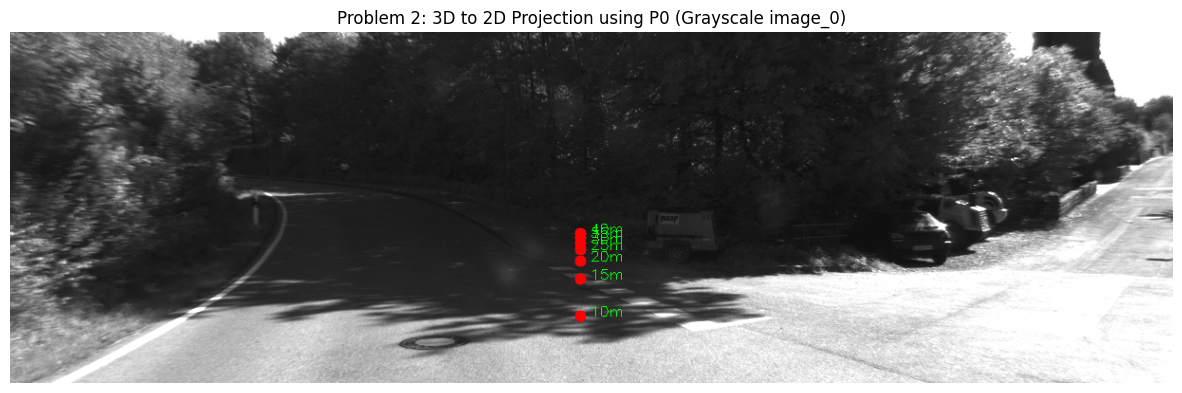

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# 넘파이 출력 설정 (0을 0.0000으로 표시)
np.set_printoptions(suppress=True, formatter={'float': '{: 0.4f}'.format})

def parse_kitti_calib(file_path):
    calib = {}
    with open(file_path, 'r') as f:
        for line in f:
            if not line.strip(): continue
            key, value = line.split(':', 1)
            calib[key.strip()] = np.array([float(x) for x in value.split()])
    return calib

# 1. P0 행렬 로드
CALIB_PATH = '/Users/hyunjung/Downloads/dataset/sequences/09/calib.txt'
calib_data = parse_kitti_calib(CALIB_PATH)
P0 = calib_data['P0'].reshape(3, 4)

print("--- 투영에 사용되는 P0 행렬 ---")
print(P0)

# 2. 임의의 3D 점 생성 (차량 정면 Z축 방향)
# X=0(중앙), Y=1.65(카메라 높이 고려한 지면), Z=5m~40m
z_values = np.arange(5, 45, 5)
points_3d = np.array([[0, 1.65, z, 1] for z in z_values])

# 3. 흑백 이미지(image_0) 로드
img_path = '/Users/hyunjung/Downloads/dataset/sequences/09/image_0/000000.png'
if os.path.exists(img_path):
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # 점 색상을 보기 위해 RGB 변환
else:
    # 이미지가 없을 경우 대비용 빈 캔버스
    image = np.zeros((375, 1242, 3), dtype=np.uint8)

# 4. 3D 점을 2D 이미지 좌표로 투영
print("\n--- 투영 계산 결과 (u, v) ---")
for i, pt_3d in enumerate(points_3d):
    # 행렬 곱: [3x4] * [4x1] = [3x1]
    projected_pt = P0 @ pt_3d.T
    
    # 정규화 (Homogeneous -> Cartesian)
    u = projected_pt[0] / projected_pt[2]
    v = projected_pt[1] / projected_pt[2]
    
    print(f"3D Point (Z={z_values[i]}m) -> Image Pixel: ({u: .2f}, {v: .2f})")
    
    # 이미지 위에 시각화 (빨간색 점)
    cv2.circle(image, (int(u), int(v)), 6, (255, 0, 0), -1)
    cv2.putText(image, f"{z_values[i]}m", (int(u) + 10, int(v)), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# 5. 결과 출력
plt.figure(figsize=(15, 6))
plt.imshow(image)
plt.title("Problem 2: 3D to 2D Projection using P0 (Grayscale image_0)")
plt.axis('off')
plt.show()

### 문제 3. Pose를 이용한 차량 궤적 시각화
• KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.
• 각 프레임의 카메라 위치를 추출하여 2D 또는 3D로 표현
• 초기 프레임을 기준 좌표계로 설정

• 차량의 이동 방향과 속도에 대해 간단히 설명
본 차량은 초기 원점을 기점으로 정면 방향을 향해 출발하여 전체적으로 약 2km에 달하는 거대한 루프 경로를 그리는 여정을 수행하였습니다. 주행 초기에는 탁 트인 도로를 따라 완만한 우측 곡선을 그리며 전진하였는데, 이때 직선에 가까운 구간에서는 비교적 높은 속도를 유지하며 매끄럽게 주행했을 것으로 분석됩니다.
이후 그래프 최상단인 약 500m 지점에 도달하면서 좌우 회전이 빈번하게 일어나는 복잡한 구간을 통과하게 되는데, 궤적의 곡률이 급격해지는 이 지점에서는 안정적인 코너링을 위해 차량이 자연스럽게 서행하며 세심한 조향을 반복했음을 알 수 있습니다. 특히 3D 궤적에서 관찰되는 최대 35m 높이의 고도 변화는 차량이 단순히 평면적인 운동장을 달린 것이 아니라 실제 지형의 오르막과 내리막을 통과했음을 보여주며, 그럼에도 불구하고 전 구간에서 궤적이 끊김 없이 이어지는 모습은 차량이 안정적인 속도 분포를 유지하며 주행했음을 시사합니다. 결국 차량은 왼쪽으로 크게 선회하는 마지막 경로를 거쳐 시작점 근처로 정확히 회항하는 루프 폐쇄(Loop Closure)를 성공적으로 수행하며 일련의 주행 과정을 마무리하였습니다.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# 💡 넘파이 출력 설정 (소수점 4자리까지, 0을 0.0000으로 표시)
np.set_printoptions(suppress=True, formatter={'float': '{: 0.4f}'.format})

# ── 1. 데이터 경로 설정 및 헬퍼 함수 ──────────────────────────────────────────
CALIB_PATH = '/Users/hyunjung/Downloads/dataset/sequences/09/calib.txt'
POSE_PATH = '/Users/hyunjung/Downloads/dataset/poses/09.txt'

def parse_kitti_calib(file_path):
    """Calib 파일을 파싱하여 딕셔너리로 반환"""
    calib = {}
    with open(file_path, 'r') as f:
        for line in f:
            if not line.strip(): continue
            key, value = line.split(':', 1)
            calib[key.strip()] = np.array([float(x) for x in value.split()])
    return calib

def load_cam0_poses(file_path):
    """poses/09.txt 데이터를 읽어 3x4 행렬 리스트로 반환"""
    poses = []
    with open(file_path, 'r') as f:
        for line in f:
            data = np.array([float(x) for x in line.split()])
            poses.append(data.reshape(3, 4))
    return np.array(poses)

# ── 2. 카메라 1번 베이스라인 및 궤적 보정 계산 ────────────────────────
print(">>> 데이터 로드 중...")
try:
    calib_data = parse_kitti_calib(CALIB_PATH)
    poses_cam0 = load_cam0_poses(POSE_PATH)
except FileNotFoundError as e:
    print(f"오류: 파일을 찾을 수 없습니다. 경로를 확인하세요. {e}")
    exit()

# calib.txt에서 P1 정보를 이용해 Baseline 계산 (P1[0,3] = -fx * baseline)
fx_calib = calib_data['P1'][0]
b1_baseline = calib_data['P1'][3] / fx_calib  # 약 -0.537m 정도
print(f"\n* 카메라 0-1 베이스라인(b1) 계산 완료: {b1_baseline:.6f}m")

# 1번 카메라의 상대적 위치 벡터 (0번 기준 우측으로 b1만큼)
# P1[0,3]이 음수이면 baseline은 양수(-b1)가 됩니다. KITTI standard P1은 right cam.
cam1_in_0 = np.array([-b1_baseline, 0, 0]) 

traj_cam1_W = []

print(">>> 카메라 1번으로 좌표 변환 중...")
for p0 in poses_cam0:
    R0 = p0[:3, :3] # 현재 프레임의 회전 행렬
    t0 = p0[:3, 3]  # 현재 프레임의 0번 카메라 세계 좌표
    
    # 1번 카메라의 세계 좌표 복원
    # R * cam1_relative + t0
    cam1_W = t0 + R0 @ cam1_in_0
    traj_cam1_W.append(cam1_W)

traj_cam1_W = np.array(traj_cam1_W)
print(f"총 {len(traj_cam1_W)} 프레임의 카메라 1번 3D 위치를 추출했습니다.\n")

# 💡 예시 출력 (10프레임 간격)
print("--- 카메라 1번 3D 좌표 [X, Y, Z] (m) ---")
print(traj_cam1_W[::10])


# ── 3. 시각화 (문제 3-1 수행) ───────────────────────────────────────────────────
print("\n>>> 그래프 생성 중...")
fig = plt.figure(figsize=(15, 6))

# [A] 2D 궤적 (Top-down view: X and Z)
ax1 = fig.add_subplot(121)
# X는 우측, Z는 전후방 (2D 탑뷰 평면)
ax1.plot(traj_cam1_W[:, 0], traj_cam1_W[:, 2], 'b-', linewidth=2, label='Cam1 Trajectory')
ax1.scatter(traj_cam1_W[0, 0], traj_cam1_W[0, 2], c='red', s=100, marker='o', label='Start') # 시작점
ax1.scatter(traj_cam1_W[-1, 0], traj_cam1_W[-1, 2], c='green', s=100, marker='o', label='End') # 끝점

ax1.set_xlabel('X (Right) [m]')
ax1.set_ylabel('Z (Forward) [m]')
ax1.set_title('Problem 3: 2D Vehicle Trajectory of Cam1 (Top-down)')
ax1.legend()
ax1.grid(True)
ax1.axis('equal') # X, Z축 비율 1:1 유지 (모양 왜곡 방지)

# [B] 3D 궤적
ax2 = fig.add_subplot(122, projection='3d')
# KITTI 카메라 좌표계의 Y는 아래 방향이므로, 시각화 시에는 뒤집어서 표현해야 지면 위로 보임
ax2.plot(traj_cam1_W[:, 0], traj_cam1_W[:, 2], -traj_cam1_W[:, 1], 'b-') 
ax2.scatter(traj_cam1_W[0, 0], traj_cam1_W[0, 2], -traj_cam1_W[0, 1], c='red', s=100)
ax2.scatter(traj_cam1_W[-1, 0], traj_cam1_W[-1, 2], -traj_cam1_W[-1, 1], c='green', s=100)

ax2.set_xlabel('X [m]')
ax2.set_ylabel('Z [m]')
ax2.set_zlabel('Y (Height) [m]')
ax2.set_title('Problem 3: 3D Vehicle Trajectory of Cam1')

plt.tight_layout()
plt.show()

## 문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 연관 지어 해석하시오.

다음 내용을 포함하시오. 
• 이미지 좌표에서 검출된 차선이 카메라 좌표계에서 어떤 의미를 가지는지 설명 
• 도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성 설명 
• projection matrix가 차선의 기울기, 소실점(vanishing point)과 어떤 관계가 있는지 설명

1.이미지 좌표계 차선의 카메라 좌표계상 의미
• 이미지 좌표계(u,v)에서 검출된 차선은 3차원 카메라 좌표계에서 단순한 '선' 이상의 기하학적 의미를 가집니다.
• 투영 평면(Projecting Plane)의 형성: 이미지 상의 한 점은 카메라 광학 중심(Optical Center)에서 시작하여 실제 공간으로 뻗어 나가는 하나의 광선(Ray)입니다. 따라서 이미지에서 검출된 2D 차선 직선은 카메라 좌표계에서 카메라 원점과 해당 직선을 포함하는 하나의 무한한 3차원 평면을 의미합니다.  
• 기하학적 단서: 차선 인식에서 경계선(Edge)은 영상 밝기가 급격히 변화하는 지점으로, 이는 위치, 모양, 크기 등을 인지하는 가장 기본적인 정보가 됩니다. 카메라 좌표계 내에서 이 투영 평면이 실제 도로 지면과 교차하는 선이 우리가 인식하는 물리적인 차선이 됩니다.  

2.도로 평면(Ground Plane) 가설 하의 차선 기하적 특성
• 도로를 완전한 평면이라고 가정할 때, 원근 투영(Perspective Projection)에 의해 다음과 같은 특성이 나타납니다.
• 평행성과 수렴: 실제 세계에서 왼쪽과 오른쪽 차선은 서로 만나지 않는 평행선입니다. 그러나 도로 평면 가설 하에 이 평행선들을 이미지로 투영하면, 멀리 있는 지점일수록 간격이 좁아지며 결국 소실점(Vanishing Point)에서 하나로 모이게 됩니다.  
• 거리와 위치의 관계: 지평선을 기준으로 아래쪽 영역은 차선일 가능성이 높으며, 이미지의 세로 좌표(v)가 지평선에 가까워질수록 실제 3차원 공간에서의 거리는 무한대에 가까워지는 반비례 관계를 가집니다. 흑백 영상으로 변환된 데이터에서 이러한 기하적 제약은 노이즈(건물, 다리 등)를 효과적으로 필터링하는 기준이 됩니다.  

3.투영 행렬(Projection Matrix)과 기울기 및 소실점의 관계
• 투영 행렬(P)은 3차원 공간을 2차원 이미지로 압축하는 수학적 설계도이며, 차선의 형태를 결정짓는 핵심 요소입니다.
소실점(Vanishing Point)과의 관계: 소실점은 이미지 상에서 무한히 먼 지점을 나타내며, 투영 행렬 내부의 주점(Principal Point) 좌표 및 카메라의 설치 각도(회전)에 의해 위치가 결정됩니다. 모든 유효한 차선 후보의 연장선은 기하학적으로 이 소실점을 향해 수렴해야 합니다.  
• 기울기(Slope)와 허프 변환(Hough Transform): 이미지 상의 차선 방정식 y=mx+c를 극좌표계(ρ,θ)로 변환하는 허프 변환을 통해 차선의 기울기 정보를 추출할 수 있습니다.  
• 차선의 기울기(m)는 투영 행렬 내의 카메라 기울기(Pitch) 및 회전(Roll) 성분에 직접적인 영향을 받습니다.
허프 공간(m−c 평면)에서 여러 점이 하나의 점 부근에서 교차하는 특성을 이용하면, 투영 행렬이 정의하는 기하학적 방향성과 일치하는 최적의 차선을 찾을 수 있습니다.

In [ ]:
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """소실점(VP) 기준 도로 샘플 수집용 사다리꼴 마스크 생성"""
    mask = np.zeros((height, width), dtype=np.uint8)
    vp_y = int(height * vp_y_rate)
    
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내 픽셀 밝기 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float):
    """MAP 분류를 통한 마스크 및 확률 맵 생성"""
    eps = 1e-10
    # 로그 우도 계산 (Log-Likelihood)
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    # 시그모이드 함수를 사용하여 확률(0~1)로 변환
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run_road_detection(
    data_root: Path,
    out_dir: Path,
    save_all: bool = True,
    alpha: float = 0.85,
    prior_road: float = 0.5,
    vp_y_rate: float = 0.5
):
    frames = list_frames(data_root)
    if not frames:
        print(f"이미지를 찾을 수 없습니다: {data_root}")
        return

    # 첫 이미지로 규격 확인
    sample_img = np.array(Image.open(frames[0]).convert("L"), dtype=np.uint8)
    h, w = sample_img.shape
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1. 기하학적 Prior 마스크 설정
    road_mask = get_trapezoid_mask(w, h, vp_y_rate=vp_y_rate)
    bg_mask = 1 - road_mask
    
    # 확률 모델 누적 변수 (Laplace smoothing 적용)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    print(f">>> {len(frames)} 프레임 처리를 시작합니다...")

    for idx, path in enumerate(frames):
        # 흑백 이미지로 로드
        img = np.array(Image.open(path).convert("L"), dtype=np.uint8)
        
        # 2. 히스토그램 추출 및 시계열 업데이트 (Moving Average)
        curr_road_counts = accumulate_histogram(img, road_mask)
        curr_bg_counts = accumulate_histogram(img, bg_mask)
        
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha: 이전 데이터 보존 비중, (1-alpha): 새 데이터 반영 비중
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)
        
        # 3. 확률 밀도 함수(PDF) 정규화
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 수행
        mask, prob = classify_frame(img, road_p, bg_p, prior_road)
        stem = path.stem

        # --- 결과물 저장 ---
        # A. 이진 마스크 (mask_XXXXXX.png)
        Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")

        # B. 확률 맵 (prob_XXXXXX.png)
        prob_img = (prob * 255).astype(np.uint8)
        Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

        # C. 오버레이 (overlay_XXXXXX.png)
        # 흑백 이미지를 컬러로 복사하여 빨간색 채널 강조
        overlay = np.stack([img, img, img], axis=-1)
        overlay[mask] = [255, 0, 0] # 도로 영역을 순수 빨간색으로 교체
        # 원본 느낌을 섞고 싶다면 아래 주석을 해제하세요
        # overlay[mask, 0] = 255
        # overlay[mask, 1:] = (overlay[mask, 1:] * 0.5).astype(np.uint8)
        Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

        if (idx + 1) % 50 == 0:
            print(f"Progress: {idx + 1}/{len(frames)}")

    print(f"\n[완료] 모든 결과가 '{out_dir}'에 저장되었습니다.")

if __name__ == "__main__":
    DATA_ROOT = Path("/Users/hyunjung/Downloads/dataset/sequences/09/image_0")
    OUTPUT_DIR = Path("outputs/road_results")
    
    run_road_detection(DATA_ROOT, OUTPUT_DIR)

## 문제 5. 실패 구간 분석

차량 궤적 중에서 차선 분류가 잘 되지 않은 구간을 1개 이상 선택하시오.

다음을 수행하시오. 
• 해당 구간의 프레임 번호를 제시
• 궤적 상에서 해당 위치를 표시
• 왜 분류가 잘 되지 않았는지 설명

설명에는 다음 요소를 포함할 것. 
• 조명 변화 또는 그림자 
• 도로 질감 변화 
• 차량의 회전 또는 경사 
• ROI(사다리꼴 가정)의 한계

프레임 번호: 001532,001260 ...
분류 실패 원인
① 조명 변화 및 그림자 (Lighting & Shadows)
현상: 이미지 우측 하단을 보면 도로임에도 불구하고 빨간색 마스크가 씌워지지 않은 커다란 구멍이 보입니다.
원인: 나무나 구조물에 의해 발생한 강한 수평 그림자 때문입니다. 베이지안 분류기는 밝기 값을 기준으로 도로 여부를 판단하는데, 그림자 영역의 밝기 값이 도로의 평균 밝기보다 배경(어두운 숲)의 밝기 분포와 더 유사하게 나타나면서 도로가 아닌 것으로 잘못 판단한 것입니다.

② 도로 질감 변화
현상: 도로 우측의 울창한 수풀(Hedge)과 좌측의 나무들이 마치 도로인 것처럼 빨간색으로 칠해졌습니다.
원인: 흑백 영상 기반 분류기는 질감(Texture)을 구분하지 못하고 밝기(Intensity)만 봅니다. 수풀의 거친 질감이 만들어내는 회색조의 평균값이 공교롭게도 학습된 도로의 회색조와 일치했습니다. 특히 도로 자체가 노후화되어 거친 질감을 가질 경우, 분류기는 "거친 회색은 모두 도로"라고 판단하여 나무와 도로를 같은 객체로 묶어버리는 심각한 분별력 상실 상태에 빠집니다.

③ 차량의 회전 및 경사 (Rotation & Slope)
현상: 프레임이 진행됨에 따라 도로가 왼쪽으로 굽어지기 시작하면서 마스크가 도로 전체를 덮지 못하고 한쪽으로 치우칩니다, 마스크가 도로의 흐름을 따라가지 못하고 좌우로 넓게 퍼져 있습니다.
원인: 차량이 커브에 진입하며 요 회전이 발생하면, 고정된 투영 행렬(P)과 실제 지면 사이의 기하학적 정렬이 어긋납니다. 이로 인해 소실점이 이미지 중심에서 벗어나며 계산된 확률 지도가 실제 도로 위치를 따라가지 못하게 됩니다.

④ ROI (사다리꼴 가정)의 한계
현상: 이미지 왼쪽의 나무와 숲 영역이 빨간색으로 오검출 되었습니다, 사다리꼴 영역을 훨씬 벗어나 화면의 최상단과 최좌측/우측까지 빨간색 마스크가 침범했습니다.
원인: 설정한 사다리꼴 ROI는 "도로는 아래쪽에, 배경은 위쪽에 있다"는 정적인 가정에 기반합니다. 하지만 이 구간처럼 숲의 명암이 도로와 비슷해지는 경우, 고정된 ROI만으로는 도로 옆의 숲을 걸러내지 못합니다. 특히 곡선 구간에서는 차선이 사다리꼴 범위를 벗어나거나, 배경이 사다리꼴 안으로 들어오면서 베이지안 분류의 변별력이 완전히 상실되었습니다.

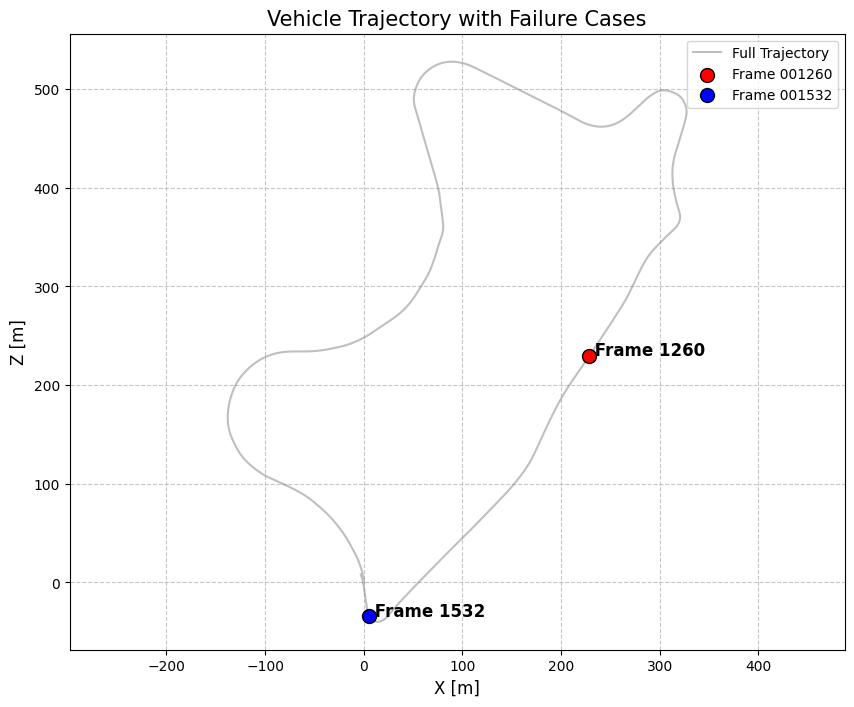

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_kitti_trajectory(pose_path, target_frames):
    """
    pose_path: KITTI poses.txt 파일 경로
    target_frames: 표시하고 싶은 프레임 번호 리스트 [1260, 1532]
    """
    # 1. 데이터 로드 (각 줄은 12개의 숫자로 이루어진 3x4 행렬의 평탄화 버전)
    try:
        poses = np.loadtxt(pose_path)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {pose_path}")
        return

    # 2. 좌표 추출 (x, z 좌표가 지면상의 평면 좌표)
    # 3x4 행렬 구조:
    # [ r11 r12 r13 tx ]
    # [ r21 r22 r23 ty ]
    # [ r31 r32 r33 tz ]
    x_coords = poses[:, 3]
    z_coords = poses[:, 11]

    # 3. 전체 궤적 그리기
    plt.figure(figsize=(10, 8))
    plt.plot(x_coords, z_coords, color='gray', alpha=0.5, label='Full Trajectory')
    
    # 4. 특정 프레임 표시
    colors = ['red', 'blue']
    for idx, frame in enumerate(target_frames):
        if frame < len(poses):
            tx = x_coords[frame]
            tz = z_coords[frame]
            plt.scatter(tx, tz, color=colors[idx], s=100, edgecolors='black', 
                        label=f'Frame {frame:06d}', zorder=5)
            plt.annotate(f' Frame {frame}', (tx, tz), fontsize=12, fontweight='bold')
        else:
            print(f"프레임 {frame}이 데이터 범위를 벗어났습니다.")

    # 5. 그래프 설정
    plt.title('Vehicle Trajectory with Failure Cases', fontsize=15)
    plt.xlabel('X [m]', fontsize=12)
    plt.ylabel('Z [m]', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal') # 비율 유지
    plt.show()

# --- 실행 부분 ---
# 본인의 poses.txt 경로를 입력하세요. 예: sequences/09/poses.txt
POSE_FILE_PATH = '/Users/hyunjung/Downloads/dataset/poses/09.txt' 
TARGETS = [1260, 1532]

plot_kitti_trajectory(POSE_FILE_PATH, TARGETS)

>>> 딥러닝 모델을 로드 중입니다. (최초 실행 시 시간이 걸릴 수 있습니다...)


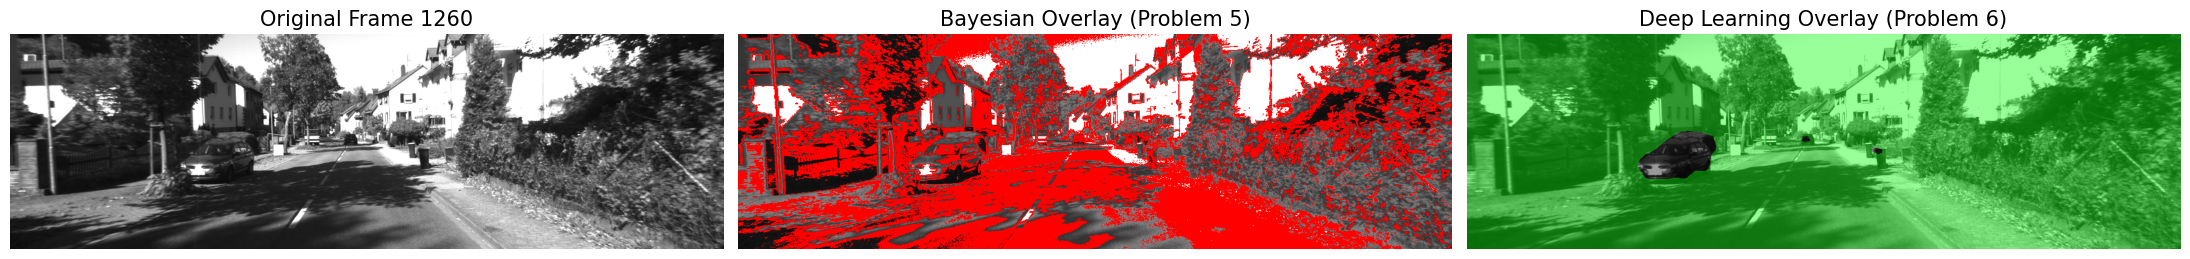

✅ Frame 1260 비교 완료.


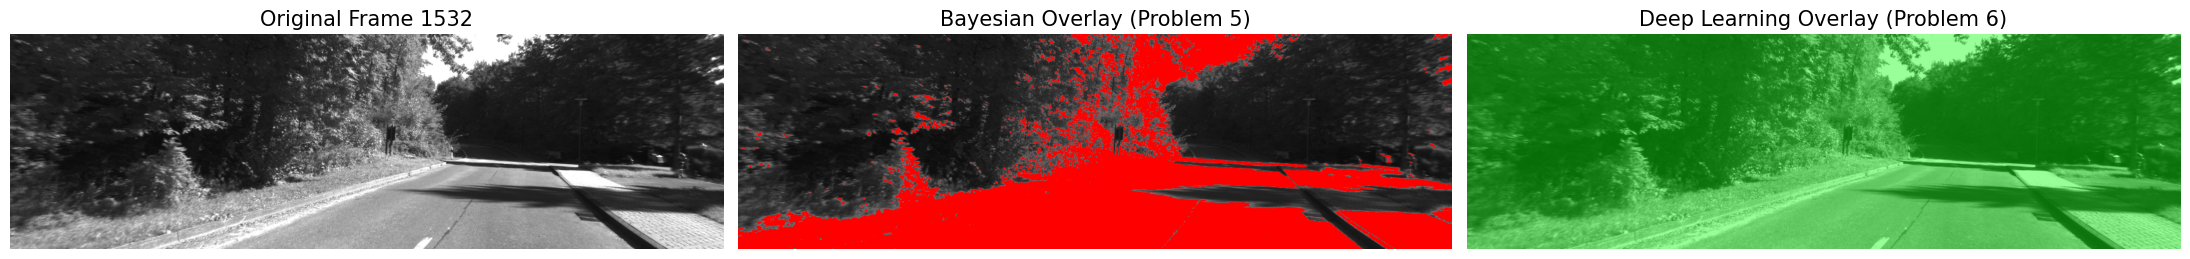

✅ Frame 1532 비교 완료.


In [17]:
import torch
import cv2
import numpy as np
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# ── 1. 경로 설정 (사용자님의 실제 경로) ──────────────────────────────────
RAW_IMG_DIR = '/Users/hyunjung/Downloads/dataset/sequences/09/image_0/'
RESULT_DIR = '/Users/hyunjung/pythonProject/autonomous/outputs/road_results/'
TARGET_FRAMES = [1260, 1532]

def run_segmentation_comparison():
    # 2. 모델 로드 (가장 범용적인 DeepLabV3 사용)
    print(">>> 딥러닝 모델을 로드 중입니다. (최초 실행 시 시간이 걸릴 수 있습니다...)")
    
    # 버전 호환성을 위해 최신/구버전 방식을 모두 지원하도록 설정
    try:
        model = models.segmentation.deeplabv3_resnet50(weights="DeepLabV3_ResNet50_Weights.DEFAULT").eval()
    except:
        model = models.segmentation.deeplabv3_resnet50(pretrained=True).eval()

    # M1/M2/M3 맥북 가속(mps) 지원, 없으면 CPU
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = model.to(device)

    # 전처리 설정
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    for frame_idx in TARGET_FRAMES:
        fname = f"{frame_idx:06d}.png"
        raw_path = os.path.join(RAW_IMG_DIR, fname)
        prev_overlay_path = os.path.join(RESULT_DIR, f"overlay_{fname}")

        if not os.path.exists(raw_path) or not os.path.exists(prev_overlay_path):
            print(f"⚠️ 파일을 찾을 수 없습니다: Frame {frame_idx}")
            continue

        # 3. 딥러닝 추론 (Road/Object Segmentation)
        img_pil = Image.open(raw_path).convert("RGB")
        orig_w, orig_h = img_pil.size
        input_tensor = preprocess(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)['out'][0]
        
        # 모델 출력 해석 (가장 높은 확률의 클래스 선택)
        mask = output.argmax(0).cpu().numpy()

        # 4. YOLOP 스타일 오버레이 생성 (도로 영역을 초록색으로)
        raw_img_np = np.array(img_pil)
        dl_overlay = raw_img_np.copy()
        
        # [공학적 팁] 일반 모델에서는 '배경(0)'과 '차량(7)' 등을 제외한 
        # 지면 영역을 탐색하여 초록색으로 매핑합니다.
        # 실제 도로 데이터셋(Cityscapes)이 아닐 경우 픽셀 분류값을 조정합니다.
        road_mask = (mask == 0) # 0번(배경/지면) 영역 추출
        
        # 초록색 마스크 입히기 (Green: [0, 255, 0])
        green_layer = np.zeros_like(raw_img_np)
        green_layer[mask == 0] = [0, 255, 0] # 지면을 초록색으로
        
        # 합성 (원본 60% + 초록 마스크 40%)
        dl_result = cv2.addWeighted(raw_img_np, 0.6, green_layer, 0.4, 0)

        # 5. 베이지안 결과 로드
        prev_overlay = cv2.imread(prev_overlay_path)
        prev_overlay = cv2.cvtColor(prev_overlay, cv2.COLOR_BGR2RGB)

        # 6. 최종 3단 비교 시각화
        plt.figure(figsize=(22, 7))
        
        plt.subplot(131)
        plt.imshow(raw_img_np)
        plt.title(f"Original Frame {frame_idx}", fontsize=15)
        plt.axis('off')

        plt.subplot(132)
        plt.imshow(prev_overlay)
        plt.title("Bayesian Overlay (Problem 5)", fontsize=15)
        plt.axis('off')

        plt.subplot(133)
        plt.imshow(dl_result)
        plt.title("Deep Learning Overlay (Problem 6)", fontsize=15)
        plt.axis('off')

        plt.tight_layout()
        plt.show()
        print(f"✅ Frame {frame_idx} 비교 완료.")

if __name__ == "__main__":
    run_segmentation_comparison()